# EX07: Bottom-up Parsing with `Ply`

## Language Processing

## LEI/2025-26

#### Nuno Macedo
Universidade do Minho

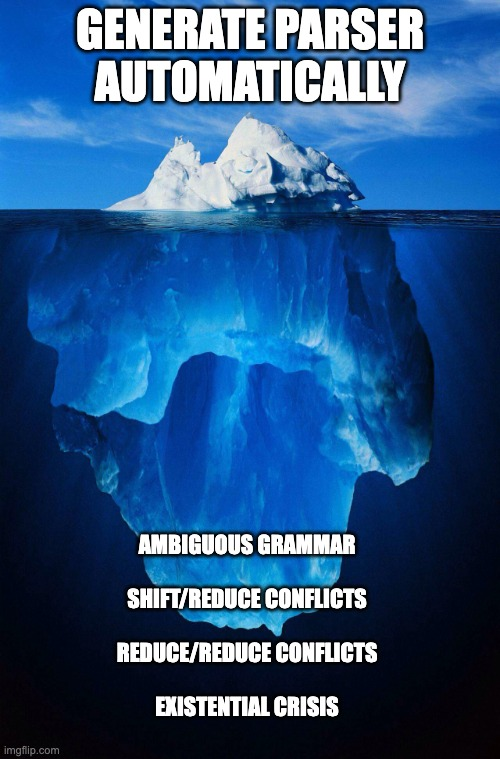

# LR($k$) parsing

- An LR($k$) parser is a shift-reduce bottom-up parser that:
  - reads input Left-to-right
  - produces a Rightmost derivation in reverse
  - uses $k$ lookahead tokens

- LR parsers must decide, as they process the input, whether to:
  - reduce symbols into a nonterminal, applying a grammar production in reverse
  - shift another input symbol into the stack

- An LR($k$) grammar must guarantee, with $k$ lookahead symbols, the absence of:
  - shift/reduce conflicts (may reduce now or shift and reduce later)
  - reduce/reduce conflicts (may reduce with different productions)

# LR parsing using `Ply.yacc`

- `lex`/`yacc` is a classical language processing pipeline using a lexer and a shift-reduce parser
  - It implements LALR(1) parsing, a simpler variant of LR(1) parsing

- The `Ply` Python module implements this pipeline, providing a parser generator

- In traditional `lex`/`yacc`, the lexer and parser specifications are given as separate files and compiled into a target language
  - In `Ply` they are written directly in Python (uses reflection)

  

In [ ]:
!pip install Ply
__file__ = "Untitled.ipynb" # needed to run Ply inside notebook

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 2.0 MB/s eta 0:00:00


⚠️ *Note:* since `Ply` relies on reflection, it is not prone to having multiple specifications in the same module
  - This leads to some conflicts when writing specifications in notebooks, which is not recommended
  - Either run the code outside the notebook, restart the notebook session if it becomes corrupted, or run the following functions

In [ ]:
def cleanLexerGlobals():
  "Remove ply.lex identifiers from the global context."
  for t in [n for n in globals() if n.startswith("t_") or n in ("tokens", "literals", "states")]:
    del globals()[t]

def cleanParserGlobals():
  "Remove ply.yacc identifiers from the global context."
  for t in [n for n in globals() if n.startswith("p_")]:
    del globals()[t]
  import os
  try: # avoid conflicts in temp files when running from notebook
    os.remove("parsetab.py")
  except FileNotFoundError:
    pass

## [`Ply.yacc`](https://ply.readthedocs.io/en/latest/ply.html#yacc) basics

- Productions are given by special functions starting with `p_`
  - You can write a different function for each production, or merge them into a single function

- The grammar productions are given in the docstring in Backus–Naur form (BNF)

- The grammar's start symbol is the one defined first

- The terminals of the grammar are the token types of the lexer
  - Usually, a `Ply.lex` lexer, but could be any other implementation

- The semantic actions are executed in *reduce* steps
  - Production functions process the return values of their children and return values upwards

- Each `p_` function receives as argument a sequence of values:
  - position 0 is reserved for its return value
  - positions from 1 onwards are the values returned by the children nodes

- The value of tokens (terminals) is the one assigned by the lexer

- Example:
  ```python
  def p_expr(p):
      """
      E   :   E   '+'   T
      """
  #   ^       ^    ^    ^
  #  p[0]    p[1] p[2] p[3]
      p[0] = p[1] + p[3]
      return p
  ```  


# Exercise 1

Consider a language to represent binary trees with integer values, such as the ones below.

- `(5 (22 () ()) (9 () (17 () ())))` ✅
- `(25 () ())` ✅
- `(57 (53 (23) ()) ())` ❌ (syntactic error)
- `(57 (53 () ()) ()` ❌ (syntactic error)

## Exercise 1.1

The CFG below, with Σ = { `(`, `)`, `INT` }, N = { `Tree`, `Value` }, $S_0$ = `Tree`, is able to generate this language.

```
p1: Tree  → ( Value Tree Tree )
p2:       | ( )
p3: Value → INT
```

Write a shift-reduce parser using `Ply.yacc` to recognize input texts generated by this grammar.

Start by writing the lexer using `Ply.lex`.


In [ ]:
import doctest

In [ ]:
def bintree(text):
  """
  >>> bintree("(25 () ())")
  Recognized!

  >>> bintree("(5 (22 () ()) (-9 () (17 () ())))")
  Recognized!

  >>> bintree("()")
  Recognized!

  >>> bintree("(")
  Unexpected token: $

  >>> bintree("(20)")
  Unexpected token: )

  >>> bintree("(20 ())")
  Unexpected token: )

  >>> bintree("(57 (53 (23) ()) ())")
  Unexpected token: )

  >>> bintree("(57 (53 () ()) ()")
  Unexpected token: $
  """
  try:
    parser.parse(text)
    print("Recognized!")
  except Exception as e:
    print(e)

doctest.run_docstring_examples(bintree, globals())

## Exercise 1.2

Adapt the production functions of the parser from the previous exercise to print the tree into the output.

In [ ]:
def print_bintree(text):
  r"""
  >>> print_bintree("(25 () ())")
  25
    x
    x

  >>> print_bintree("(5 (22 () ()) (-9 () (17 () ())))")
  5
    22
      x
      x
    -9
      x
      17
        x
        x

  >>> print_bintree("()")
  x

  >>> print_bintree("(5 (22 (13 () ()) (29 () ())) (9 () (17 (34 () ()) ())))")
  5
    22
      13
        x
        x
      29
        x
        x
    9
      x
      17
        34
          x
          x
        x
  """
  try:
    parser.parse(text)
  except Exception as e:
    print(e)

doctest.run_docstring_examples(print_bintree, globals())

## Exercise 1.3

Add *semantic actions* to the production functions of the parser to find the maximum value of the tree.

In [ ]:
def max_bintree(text):
  r"""
  >>> max_bintree("(25 () ())")
  25

  >>> max_bintree("(5 (22 () ()) (-9 () (17 () ())))")
  22

  >>> max_bintree("()")
  None

  >>> max_bintree("(5 (22 (13 () ()) (29 () ())) (9 () (17 (34 () ()) ())))")
  34

  >>> max_bintree("(-3 (-22 () ()) (-9 () ()))")
  -3
  """
  try:
    print(parser.parse(text))
  except Exception as e:
    print(e)

doctest.run_docstring_examples(max_bintree, globals())

## Exercise 1.4

Add *semantic actions* to the production function of the parser to extract an intermediate representation of the binary tree as Python *nested tuples*. Consider the empty tree to be represented by `None`.

In [ ]:
def tuple_bintree(text):
  r"""
  >>> tuple_bintree("(25 () ())")
  (25, None, None)

  >>> tuple_bintree("(5 (22 () ()) (-9 () (17 () ())))")
  (5, (22, None, None), (9, None, (17, None, None)))

  >>> tuple_bintree("()")
  None

  >>> tuple_bintree("(5 (22 (13 () ()) (29 () ())) (9 () (17 (34 () ()) ())))")
  (5, (22, (13, None, None), (29, None, None)), (9, None, (17, (34, None, None), None)))
  """
  try:
    print(parser.parse(text))
  except Exception as e:
    print(e)

doctest.run_docstring_examples(tuple_bintree, globals())

# Exercise 2

Consider a language to write propositional logic formulas.

- `A ∨ X ∧ ⊤ ⇒ (A ∨ ¬X)` ✅
- `A ∨ X ¬Y` ❌ (syntactic error)
- `∨ X ∧ ⊥` ❌ (syntactic error)

## Exercise 2.1

The CFG below, with Σ = { `(`, `)`, `∨`, `∧`, `⇒`, `¬`, `⊤`, `⊥`, `ID` }, N = { `Impl`, `Conj`, `Disj`, `Lit` }, $S_0$ = `Impl`, is able to generate this language.

```
p1:  Impl → Impl ⇒ Disj
p2:       | Disj
p3:  Disj → Disj ∨ Conj
p4:       | Conj
p5:  Conj → Conj ∧ Lit
p6:       | Lit
p7:  Lit  → ID  
p8:       | ⊤
p9:       | ⊥
p10:      | ¬ Lit
p11:      | ( Impl )
```

Write a shift-reduce parser using `Ply.yacc` to recognize input texts generated by this grammar.

Start by writing the lexer using `Ply.lex`. Consider a C-like concrete syntax for the logical operators, `=>`, `||`, `&&`, `!`, and keywords for constants `true` and `false`.

In [ ]:
def propexpr(text):
  """
  >>> propexpr("A || X")
  Recognized!

  >>> propexpr("A || X && true")
  Recognized!

  >>> propexpr("X")
  Recognized!

  >>> propexpr("!(A || X) => !false")
  Recognized!

  >>> propexpr("A || X && true => (A || !X)")
  Recognized!

  >>> propexpr("A || X !Y")
  Unexpected token: NOT

  >>> propexpr("|| X && false")
  Unexpected token: OR

  >>> propexpr("!(A || B")
  Unexpected token: $
  """
  try:
    parser.parse(text)
    print("Recognized!")
  except Exception as e:
    print(e)

doctest.run_docstring_examples(propexpr, globals())

## Exercise 2.2

Add *semantic actions* to the production functions of the parser to extract an intermediate representation of the propositional expressions as Python *nested tuples*. Use the first element of the tuple to register the type of the operator.


In [ ]:
def tuple_propexpr(text):
  """
  >>> tuple_propexpr("true")
  ('true',)

  >>> tuple_propexpr("true || false")
  ('OR', ('true',), ('false',))

  >>> tuple_propexpr("true && false")
  ('AND', ('true',), ('false',))

  >>> tuple_propexpr("A || X")
  ('OR', ('A',), ('X',))

  >>> tuple_propexpr("A || X || false")
  ('OR', ('OR', ('A',), ('X',)), ('false',))

  >>> tuple_propexpr("A && X")
  ('AND', ('A',), ('X',))

  >>> tuple_propexpr("A || false && X")
  ('OR', ('A',), ('AND', ('false',), ('X',)))

  >>> tuple_propexpr("A || (false && X)")
  ('OR', ('A',), ('AND', ('false',), ('X',)))

  >>> tuple_propexpr("(A || true) && X ")
  ('AND', ('OR', ('A',), ('true',)), ('X',))

  >>> tuple_propexpr("!A && X")
  ('AND', ('NOT', ('A',)), ('X',))

  >>> tuple_propexpr("!(A && X)")
  ('NOT', ('AND', ('A',), ('X',)))

  >>> tuple_propexpr("false => true => false")
  ('IMPLIES', ('IMPLIES', ('false',), ('true',)), ('false',))

  >>> tuple_propexpr("(false => true) => false")
  ('IMPLIES', ('IMPLIES', ('false',), ('true',)), ('false',))

  >>> tuple_propexpr("false => (true => false)")
  ('IMPLIES', ('false',), ('IMPLIES', ('true',), ('false',)))
  """
  try:
    print(parser.parse(text))
  except Exception as e:
    print(e)

doctest.run_docstring_examples(tuple_propexpr, globals())

## Exercise 2.3

Assume that you are given a dictionary that assigns to each identifier in the propositional expression a value `True` or `False`. Add *semantic actions* to the production functions of the parser to evaluate the value of an expression.

In [ ]:
def eval_propexpr(eval,text):
  """
  >>> eval_propexpr({}, "true")
  True

  >>> eval_propexpr({}, "true || false")
  True

  >>> eval_propexpr({}, "true && false")
  False

  >>> eval_propexpr({"A":True,"X":False}, "A || X")
  True

  >>> eval_propexpr({"A":True,"X":False}, "A || X || false")
  True

  >>> eval_propexpr({"A":True,"X":False}, "A && X")
  False

  >>> eval_propexpr({"A":False,"X":True}, "A || false && X")
  False

  >>> eval_propexpr({"A":False,"X":True}, "A || (false && X)")
  False

  >>> eval_propexpr({"A":False,"X":True}, "(A || true) && X ")
  True

  >>> eval_propexpr({"A":True,"X":False}, "!A && X")
  False

  >>> eval_propexpr({"A":True,"X":False}, "!(A && X)")
  True

  >>> eval_propexpr({}, "false => true => false")
  False

  """
  try:
    parser.vars = eval # add context to parser
    print(parser.parse(text))
  except Exception as e:
    print(e)

doctest.run_docstring_examples(eval_propexpr, globals())

# Exercise 3

Consider the [`cinema.json`](https://elearning.uminho.pt/bbcswebdav/pid-1774485-dt-content-rid-13918576_1/xid-13918576_1?xythos-download=true) file containing a JSON database of movies.


In [ ]:
from google.colab import files
uploaded = files.upload()

## Exercise 3.1

Write a lexer and a parser using `Ply` to identify all movies in which cast members have participated. The result should be a dictionary from cast member to list of movies.

In [ ]:
def cast():
  """
  >>> cast()['Jeff Goldblum']
  ['Independence Day', 'Jurassic Park']

  >>> cast()['Sigourney Weaver']
  ['Avatar', 'Galaxy Quest', 'Aliens', 'Alien']

  >>> cast()['Harrison Ford']
  ['Blade Runner 2049', 'Blade Runner', 'Star Wars: A New Hope']

  >>> cast()['Emily Blunt']
  ['Edge of Tomorrow', 'Looper']
  """
  with open("cinema.json", "r") as f:
    content = f.read()

  return parser.parse(content)

doctest.run_docstring_examples(cast, globals())

## Exercise 3.2

Adapt the parser from the previous exercise to extract the complete JSON database as a list of Python dictionaries.

In [ ]:
def db():
  """
  >>> len(db())
  51

  >>> db()[3]
  {'title': 'Blade Runner', 'year': 1982, 'cast': ['Harrison Ford', 'Rutger Hauer', 'Sean Young'], 'genres': ['Sci-Fi', 'Thriller']}

  >>> db()[33]
  {'title': 'Rise of the Planet of the Apes', 'year': 2011, 'cast': ['James Franco', 'Andy Serkis'], 'genres': ['Sci-Fi', 'Action']}
  """
  with open("cinema.json", "r") as f:
    content = f.read()

  return parser.parse(content)

doctest.run_docstring_examples(db, globals())

# Exercise 4

Consider an interactive calculator with the following commands:

 -  `! e` - print the value of an expression `e`
 -  `? v` - ask the user for a value for variable `v`
 -  `v = e` - assign value of expression `e` to variable `v`
 -  `*` - dump to the output the value of all variables
 -  `#` - close the calculator

 Write a lexer and a parser with semantic actions to interactively evaluate such expressions.

# Exercise 5

A few years ago, people used to have fun creating "artworks" using typewriter characters. Later, this trend continued with early computers and VT100-style monitors.

In this exercise, you must process an input text containing a "recipe" and produce one of these images made only of characters.

- In the recipe, blocks are separated by spaces;
- Each block may be:
  - `nl` - a line break;
  - *`nx`* - where $n$ is the number of times you should repeat the character $x$.
  - $x$ may be a single symbol or one of the following abbreviations
    - `sp` = white space
    - `bS` = backSlash `\`
    - `sQ` = singleQuote `'`
    - `nl` = line break

- For instance
  - `4z` ⟶ `zzzz`
  - `1{` ⟶ `{`
  - `10=` ⟶ `==========`
  - `5bS` ⟶ `\\\\\`
  - `27` ⟶ `77`
  - `123` ⟶ `333333333333` (the last character is the symbol to repeat)

- Additional reading:
  - [ASCII character art](https://asciiart.cc)
  - [Book about the topic](https://loriemerson.net/2013/01/18/d-i-y-typewriter-art/)
  - [Video about the topic](https://www.youtube.com/watch?v=kyK5WvpFxqo)


## Exercise 5.1

- Create a `Ply` parser that converts an input string with a ASCII art recipe, and outputs the various lines drawing the expected figure.

- Additionally, check the following rules:
  - 5 <= recipe length <= 1000
  - The recipe cannot contain quotes
  - The recipe must contain at least one `nl`.

In [ ]:
def draw(text):
  r"""
  >>> draw("1sp 1/ 1bS 1_ 1/ 1bS nl 1( 1sp 1o 1. 1o 1sp 1) nl 1sp 1> 1sp 1^ 1sp 1< nl 2sp 3|")
   /\_/\
  ( o.o )
   > ^ <
    |||

  >>> draw("2sp 1^ nl 1sp 3^ nl 5^ nl 2sp 1|")
    ^
   ^^^
  ^^^^^
    |

  >>> draw("2sp 1/ 1\\ nl 2sp 1| 1| nl 2sp 1| 1| nl 1/ 1| 2_ 1| 1\\ nl 1sp 1/ 1_ 1_ 1\\ nl 2sp 1| 1| nl 2sp 1v 1v")
    /\
    ||
    ||
  /|__|\
   /__\
    ||
    vv
  """
  try:
    print(parser.parse(text))
  except Exception as e:
    print(e)

doctest.run_docstring_examples(draw, globals())

## Exercise 5.2

As an additional challenge, now implement a parser to perform the reverse operation: from a given ASCII art string, create the recipe that can generate it.

Here are a couple of examples, extracted from the first provided reference.

```txt
  ,-.
  \_/
 {|||)<
  / \
  `-^   
```

```txt
        :';t)/!||||(//L+)'(-\\/ddjWWW#######WmKK(\!(/-|J=/\\t/!-/\!_L\)
        |-!/(!-)\L\)/!\5(!.!LWW###################WK/|!\\\\/!;\/\T\/((\
        |!'//\//(-!t\Y/\L!m#####M####################WLt\\!)\/J-//)/;t\
        --/-.\.\/\.!)///m######K#######################WK!/!-( )-!,|/\
        //,\--`--!-/\(q#######DD##########################L\\\\-!!//!\\
        -.-!\'!!\-\/:W########N############################W,).'-.-/\-'
        !.\!-!-!`!-!W#######P|+~**@@@#######################W/,/'\-/,\7
        --`,-- -/.:W###*P!'          \`Z8#####################;,\\`,\,\
        `.'.'\`-.-d##5'-           -- '-:V@##########W#########_\-!-\\-
        `, -,.'/,G##K- '               - )7KM###################\-----/
        - '-  --:##@;                    -!ZZ###################W! \'!-
         '-.`- G###|.                    `,D8K###################|/-.-/
        -' ,-//###@)                      -)ZWMW##################\` _\
        - ' .:Yd###!                     `-!(K5K##################|(/L|
          - :\G###Z-                    ` ! -;55ZZ#################)(4)
         . -!W####!\                     `  ' !-tVG################XNVZ
           tt####@-.                        `  ')(W################D)8@
           )8#####\                         .-`-/KW#################KD#
          ||Z####W!-              .::,\.. -,;\bZKK######8#K#########(#8
          KN8#####( ,:!/GG_      d4KW8ZKW#WWK#W#88#######W##########WK#
         )/8K###K#W#WP~~~T4(    dW##7'___L#M####MM8W###W############bM8
        \!48#K####8##W*###WY;   WRob+~~######*ff/\NM8###############WW#
        .\\KW###W#,~t' !*~!',  -M@)    `~`,),' '.`K#################@KW
        .'8M###### -'..j/Z''    @//-  ,,\\+\'    :|W######M###########8
        :\#8#K###D              \!`             !:Z8###8@#####8W#W###8M
        q8W5######             `!-             `-)8##################M8
        8WZ8#M####-             /  .          .\tK############@######ZJ
        #W#@K###W#|              //           \\tW@###@K##W##W###K###Wm
        ##8#M#8###P-            -=/,         /;D8W##############@###W##
        #8###M@####\-      ,   _)jJ;        -((WKK#####W####W##K######K
        ###W@K##K##);     `\..KW##WK       )X)KW#M##W###MW##@#W######8#
        #K#W####@#@@/;-     ~M####M\    ,.\\=)D8W##W###W##########8W##@
        ####MW######(`\\'     PPK((.:|/!-\-/)8XN@WMK#######W##MK#@#####
        ##8##MK#W#@#b!--\)L_. .(ZLWbW#\'- ,-N|/KM#######W###@########W#
        ##KW###K#W###/-  !``~~Yff*N5f -' -.\))KK#######MK##W###M8W#W###
        #W###K@K######J--    .._dd/;)/- !//)NK#8W##########8########M#K
        ##8W#K###W#####W!.   `YY\)\\)\7(-)4dW#8#@###K#W#######8########
        M####8##K#KW###W#/,       '-\\//)88W#M#@#K##M###@##M#8##@#W#8#M
        ZW#W#M#K##########m       -)!/LtWW#W##@#W#####KW#######W###K###
        K##W#####W#M#8#####KL   .-//dD##8W#K######8##########MK###W##M#
        tN#W##W#W#M##########bb4dKW#@##W##K####MK####8###########W#####
        )NM#8W##@###@##############@##@##8##K#W####M##K##K#@###8##M####
        (tMM###W##M8####@####@###@#########@####8W##8W################M
        tNZ##K###W####@#####8###/4N##8#W##W##M#8#MK#M8#K######W########
        M/K@8###M@###M##########|!t*Z#N####8##M8Z@ZZ#M###@#W#####K###W#
        WVd4M######@############D,\`(+KKZD#8WK#5@84VZ#WM############W##
        K5WM8#8W#W########8######,,-!/))ZK5@K4)@+(/XV/Z###@###W###M####
        +8WN@##@K##W###W#########b.-.\!||\X(5)Z/7\\\t5/K########W######
        8M8###@###@##8#########KDbt! !.-!t`(-\\!.\/.\!ZdG###W#MW###G###
        ~~~~~`~~~~~~~~~~~~~~~~'~` ''  ' ` ` ' '   `   ``~`~`~`~~~~'~~~~  
```

# Exercise 6

Consider a simple imperative language with conditional and repetition statements. Below as a few example programs expected to be valid in this language.


In [ ]:
ex0 = '''
  (read a)
  (= x (* a 10))
  (write x)
  '''

ex1 = '''
  (read a)
  (read b)
  (read c)
  (if (> a b)
      ((if (> a c)
          ((write a))
          ((write c))
      ))
      ((if (> b c)
          ((write b))
          ((write c))
      ))
  )
  '''

ex2 = '''
  (read a)
  (= f 1)
  (while (> a 1)
      (
          (= f (* f a))
          (= a (- a 1))
      )
  )
  (write f)
  '''

## Exercise 6.1

Write a parser to recognize syntactically valid programs written in this language.

In [ ]:
ex3 = '''
  (read a)
  (= f 1)
  (while
      (
          (= f (* f a))
          (= a (- a 1))
      )
  )
  (write f)
  '''

In [ ]:
def parse(text):
  r"""
  >>> parse(ex0)
  Recognized!

  >>> parse(ex1)
  Recognized!

  >>> parse(ex2)
  Recognized!

  >>> parse(ex3)
  Unexpected token: (
  """
  try:
    parser.parse(text)
    print("Recognized!")
  except Exception as e:
    print(e)

doctest.run_docstring_examples(parse, globals())

## Exercise 6.2

Extend the parser to perform *semantic validation* for programs written in this language.

You should check the following rules:
- Variables used in expressions must have been declared/assigned before
- The program is correctly typed (e.g., operand types, conditional expressions, ...)

In [ ]:
ex4 = '''
  (read a)
  (= f 1)
  (while (< b 1)
      (
          (= f (* f a))
          (= a (- a 1))
      )
  )
  (write f)
  '''

ex5 = '''
  (read a)
  (= f 1)
  (while (+ a 1)
      (
          (= f (* f a))
          (= a (- a 1))
      )
  )
  (write f)
  '''

In [ ]:
def parse(text):
  r"""
  >>> parse(ex0)
  Recognized!

  >>> parse(ex1)
  Recognized!

  >>> parse(ex2)
  Recognized!

  >>> parse(ex4)
  Undeclared variable: b

  >>> parse(ex5)
  Unexpected token: +
  """
  try:
    parser.vars = []
    parser.parse(text)
    print("Recognized!")
  except Exception as e:
    print(e)

doctest.run_docstring_examples(parse, globals())

## Exercise 6.3

Adapt the parser to generate *abstract syntax trees* (ASTs) from programs written in this language, with expressions annotated with type information.

In [ ]:
def parse(text):
  r"""
  >>> parse(ex0)
  [('read', 'a'), ('assign', 'x', ('mul', 'num', ('a', 'num'), (10, 'num'))), ('write', 'x')]

  >>> parse(ex1)
  [('read', 'a'), ('read', 'b'), ('read', 'c'), ('if', ('gt', 'bool', ('a', 'num'), ('b', 'num')), [('if', ('gt', 'bool', ('a', 'num'), ('c', 'num')), [('write', 'a')], [('write', 'c')])], [('if', ('gt', 'bool', ('b', 'num'), ('c', 'num')), [('write', 'b')], [('write', 'c')])])]

  >>> parse(ex2)
  [('read', 'a'), ('assign', 'f', (1, 'num')), ('while', ('gt', 'bool', ('a', 'num'), (1, 'num')), [('assign', 'f', ('mul', 'num', ('f', 'num'), ('a', 'num'))), ('assign', 'a', ('sub', 'num', ('a', 'num'), (1, 'num')))]), ('write', 'f')]
  """
  try:
    parser.vars = []
    print(parser.parse(text))
  except Exception as e:
    print(e)

doctest.run_docstring_examples(parse, globals())

# Exercise 7

Consider the following grammar to recognize simple statements.

```
p1: Statements : Statements Statement
p2:            | Statement
p3: Statement : ID = Expr
p4:           | Expr
p5: Expr : INT
p6:      | ID
```

## Exercise 7.1

The grammar above is **not** LR(0). Build the LR(0) automaton and identify conflicts.

## Exercise 7.2

The grammar **is** however SLR(1) (and thus, also LALR(1) and LR(1)). Show how $\mathrm{FOLLOW}$ sets can be used to resolve the LR(0) conflicts.

**Bonus**: Build the action and goto tables.

## Exercise 7.3

Implement a parser in `Ply` that extracts the AST of input texts recognized by this grammar.

In [ ]:
def statements(text):
  """
  >>> statements("x")
  [('Expr', 'x')]

  >>> statements("x = 10")
  [('Assign', 'x', 10)]

  >>> statements("x y = 10 z")
  [('Expr', 'x'), ('Assign', 'y', 10), ('Expr', 'z')]

  >>> statements("y = 10 z = a x")
  [('Assign', 'y', 10), ('Assign', 'z', 'a'), ('Expr', 'x')]

  >>> statements("x = x x = x x")
  [('Assign', 'x', 'x'), ('Assign', 'x', 'x'), ('Expr', 'x')]

  >>> statements("x = y = z")
  Unexpected token: =

  >>> statements("x y z")
  [('Expr', 'x'), ('Expr', 'y'), ('Expr', 'z')]
  """
  try:
    print(parser.parse(text))
  except Exception as e:
    print(e)

doctest.run_docstring_examples(statements, globals())

-- Nuno Macedo, 2026-04-21